
# Laboratorio Machine Learning: Reducción de Dimensionalidad
## PCA, t-SNE y UMAP

**Universidad de Ingeniería y Tecnología - UTEC**

---

### Integrantes del Grupo:

1. **Nombre Completo:** David Ricardo Jimenez Rivera
2. **Nombre Completo:** Jose Carlos Nomberto Montenegro
3. **Nombre Completo:** Herles Alejandro Pinedo Rivera
4. **Nombre Completo:** ___________________________________

**Fecha:** 21/02/2026

---

## Objetivo del Laboratorio

En este laboratorio aplicarás técnicas de reducción de dimensionalidad (**PCA**, **t-SNE** y **UMAP**) a tres casos de estudio diferentes. Tu objetivo es:

1. Analizar cada dataset
2. Determinar qué técnica es más apropiada para cada caso
3. Aplicar la técnica seleccionada
4. Visualizar y analizar los resultados
5. Justificar tu elección

**Instrucciones:**
- Completa todos los apartados marcados con `# TODO:`
- Justifica tus decisiones en las celdas de markdown
- Al final, redacta conclusiones sobre lo aprendido

---

## Instalación de Librerías

Ejecuta la siguiente celda para instalar las librerías necesarias:

In [ ]:
# Instalar librerías necesarias
!pip install numpy pandas matplotlib seaborn scikit-learn umap-learn

---

## Documentación de las Técnicas

Antes de comenzar, revisa la documentación oficial de cada técnica:

### PCA (Principal Component Analysis)
- **Documentación Scikit-learn:** https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- **Tutorial:** https://scikit-learn.org/stable/modules/decomposition.html#pca

### t-SNE (t-Distributed Stochastic Neighbor Embedding)
- **Documentación Scikit-learn:** https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
- **Tutorial:** https://scikit-learn.org/stable/modules/manifold.html#t-sne

### UMAP (Uniform Manifold Approximation and Projection)
- **Documentación UMAP:** https://umap-learn.readthedocs.io/en/latest/
- **Parámetros básicos:** https://umap-learn.readthedocs.io/en/latest/parameters.html
- **Tutorial básico:** https://umap-learn.readthedocs.io/en/latest/basic_usage.html

---

## Importar Librerías

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

/Users/herivera/miniforge3/envs/ds_scraping/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

# CASO 1: Indicadores Socioeconómicos de Países

## Descripción del Dataset

Este dataset contiene indicadores socioeconómicos de diferentes países:
- PIB per cápita
- Esperanza de vida
- Años de escolaridad
- Tasa de mortalidad infantil
- Acceso a internet
- Entre otros indicadores

**Fuente:** Banco Mundial y Naciones Unidas

### 1.1. Cargar Dataset

In [6]:
# Descargar dataset de indicadores socioeconómicos
import urllib.request

url = "https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv"

# Para este ejercicio, crearemos un dataset sintético basado en correlaciones lineales
# que simula indicadores socioeconómicos reales
np.random.seed(42)
n_countries = 150

# Variable base: nivel de desarrollo (latente)
desarrollo = np.random.randn(n_countries)

# Variables correlacionadas linealmente con el desarrollo
data_caso1 = pd.DataFrame({
    'PIB_per_capita': 10000 + desarrollo * 8000 + np.random.randn(n_countries) * 1500,
    'Esperanza_vida': 65 + desarrollo * 8 + np.random.randn(n_countries) * 2,
    'Escolaridad': 8 + desarrollo * 3 + np.random.randn(n_countries) * 0.8,
    'Mortalidad_infantil': 30 - desarrollo * 10 + np.random.randn(n_countries) * 3,
    'Acceso_internet': 40 + desarrollo * 25 + np.random.randn(n_countries) * 8,
    'Consumo_energia': 2000 + desarrollo * 1500 + np.random.randn(n_countries) * 400,
    'Urbanizacion': 50 + desarrollo * 20 + np.random.randn(n_countries) * 5,
    'Inflacion': 5 - desarrollo * 2 + np.random.randn(n_countries) * 1.5,
    'Desempleo': 8 - desarrollo * 3 + np.random.randn(n_countries) * 2,
    'Inversion_educacion': 3 + desarrollo * 1.5 + np.random.randn(n_countries) * 0.5
})

# Etiquetas basadas en nivel de desarrollo
labels_caso1 = pd.Series(pd.cut(desarrollo, bins=3, labels=['En Desarrollo', 'Emergente', 'Desarrollado']))

print(f"Dataset cargado: {data_caso1.shape[0]} países, {data_caso1.shape[1]} indicadores")
print("\nPrimeras filas:")
data_caso1.head()

Dataset cargado: 150 países, 10 indicadores

Primeras filas:


,PIB_per_capita,Esperanza_vida,Escolaridad,Mortalidad_infantil,Acceso_internet,Consumo_energia,Urbanizacion,Inflacion,Desempleo,Inversion_educacion
0,14349.452500,67.315723,9.439999,27.303824,45.031988,2892.540553,56.806470,4.194408,4.169631,4.134252
1,9413.557905,62.773524,8.349321,28.616147,25.729916,1635.268023,49.213732,4.632420,4.810832,2.517011
2,14161.471222,71.676096,9.154485,26.131932,48.385227,2983.030736,65.423922,3.888069,7.139860,3.562433
3,22532.619397,78.404979,12.972327,18.836615,86.504881,4795.925530,81.763966,2.768887,4.949221,5.282858
4,8566.381712,63.084970,6.873334,33.581838,26.550975,1725.209565,42.565407,5.541597,7.549439,2.563678


### 1.2. Explorar el Dataset

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PIB_per_capita       150 non-null    float64
 1   Esperanza_vida       150 non-null    float64
 2   Escolaridad          150 non-null    float64
 3   Mortalidad_infantil  150 non-null    float64
 4   Acceso_internet      150 non-null    float64
 5   Consumo_energia      150 non-null    float64
 6   Urbanizacion         150 non-null    float64
 7   Inflacion            150 non-null    float64
 8   Desempleo            150 non-null    float64
 9   Inversion_educacion  150 non-null    float64
dtypes: float64(10)
memory usage: 11.8 KB
None

Estadísticas descriptivas:
       PIB_per_capita  Esperanza_vida  Escolaridad  Mortalidad_infantil  \
count      150.000000      150.000000   150.000000           150.000000   
mean      9448.229686       64.451342     7.6

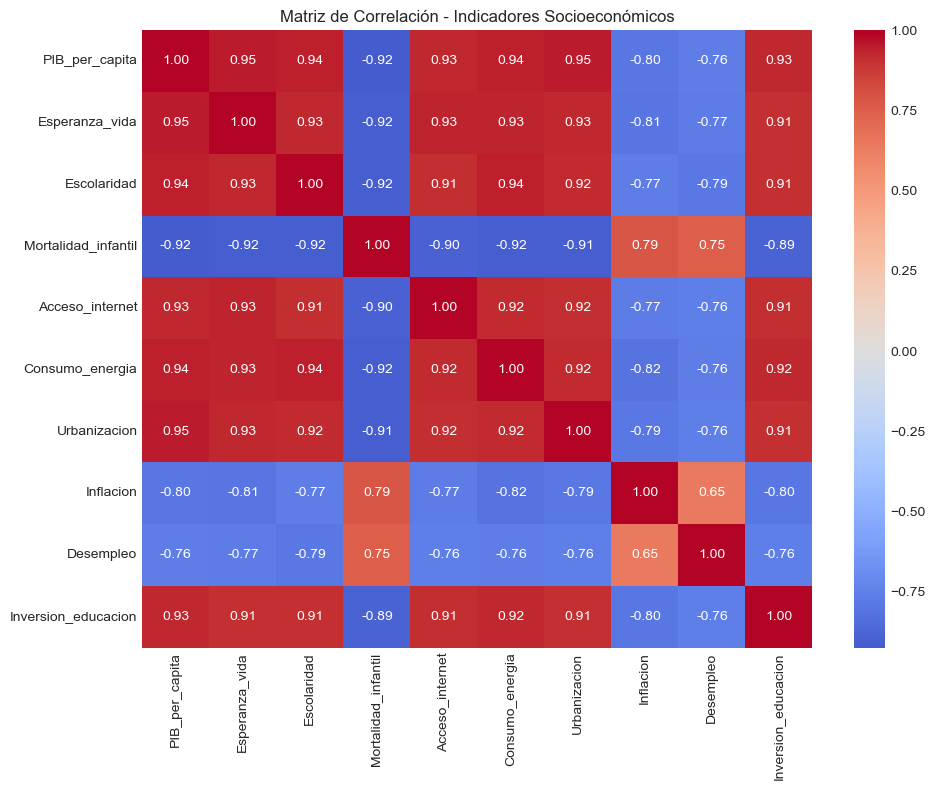

In [7]:
# Información básica
print("Información del dataset:")
print(data_caso1.info())

print("\nEstadísticas descriptivas:")
print(data_caso1.describe())

# Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(data_caso1.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación - Indicadores Socioeconómicos')
plt.tight_layout()
plt.show()

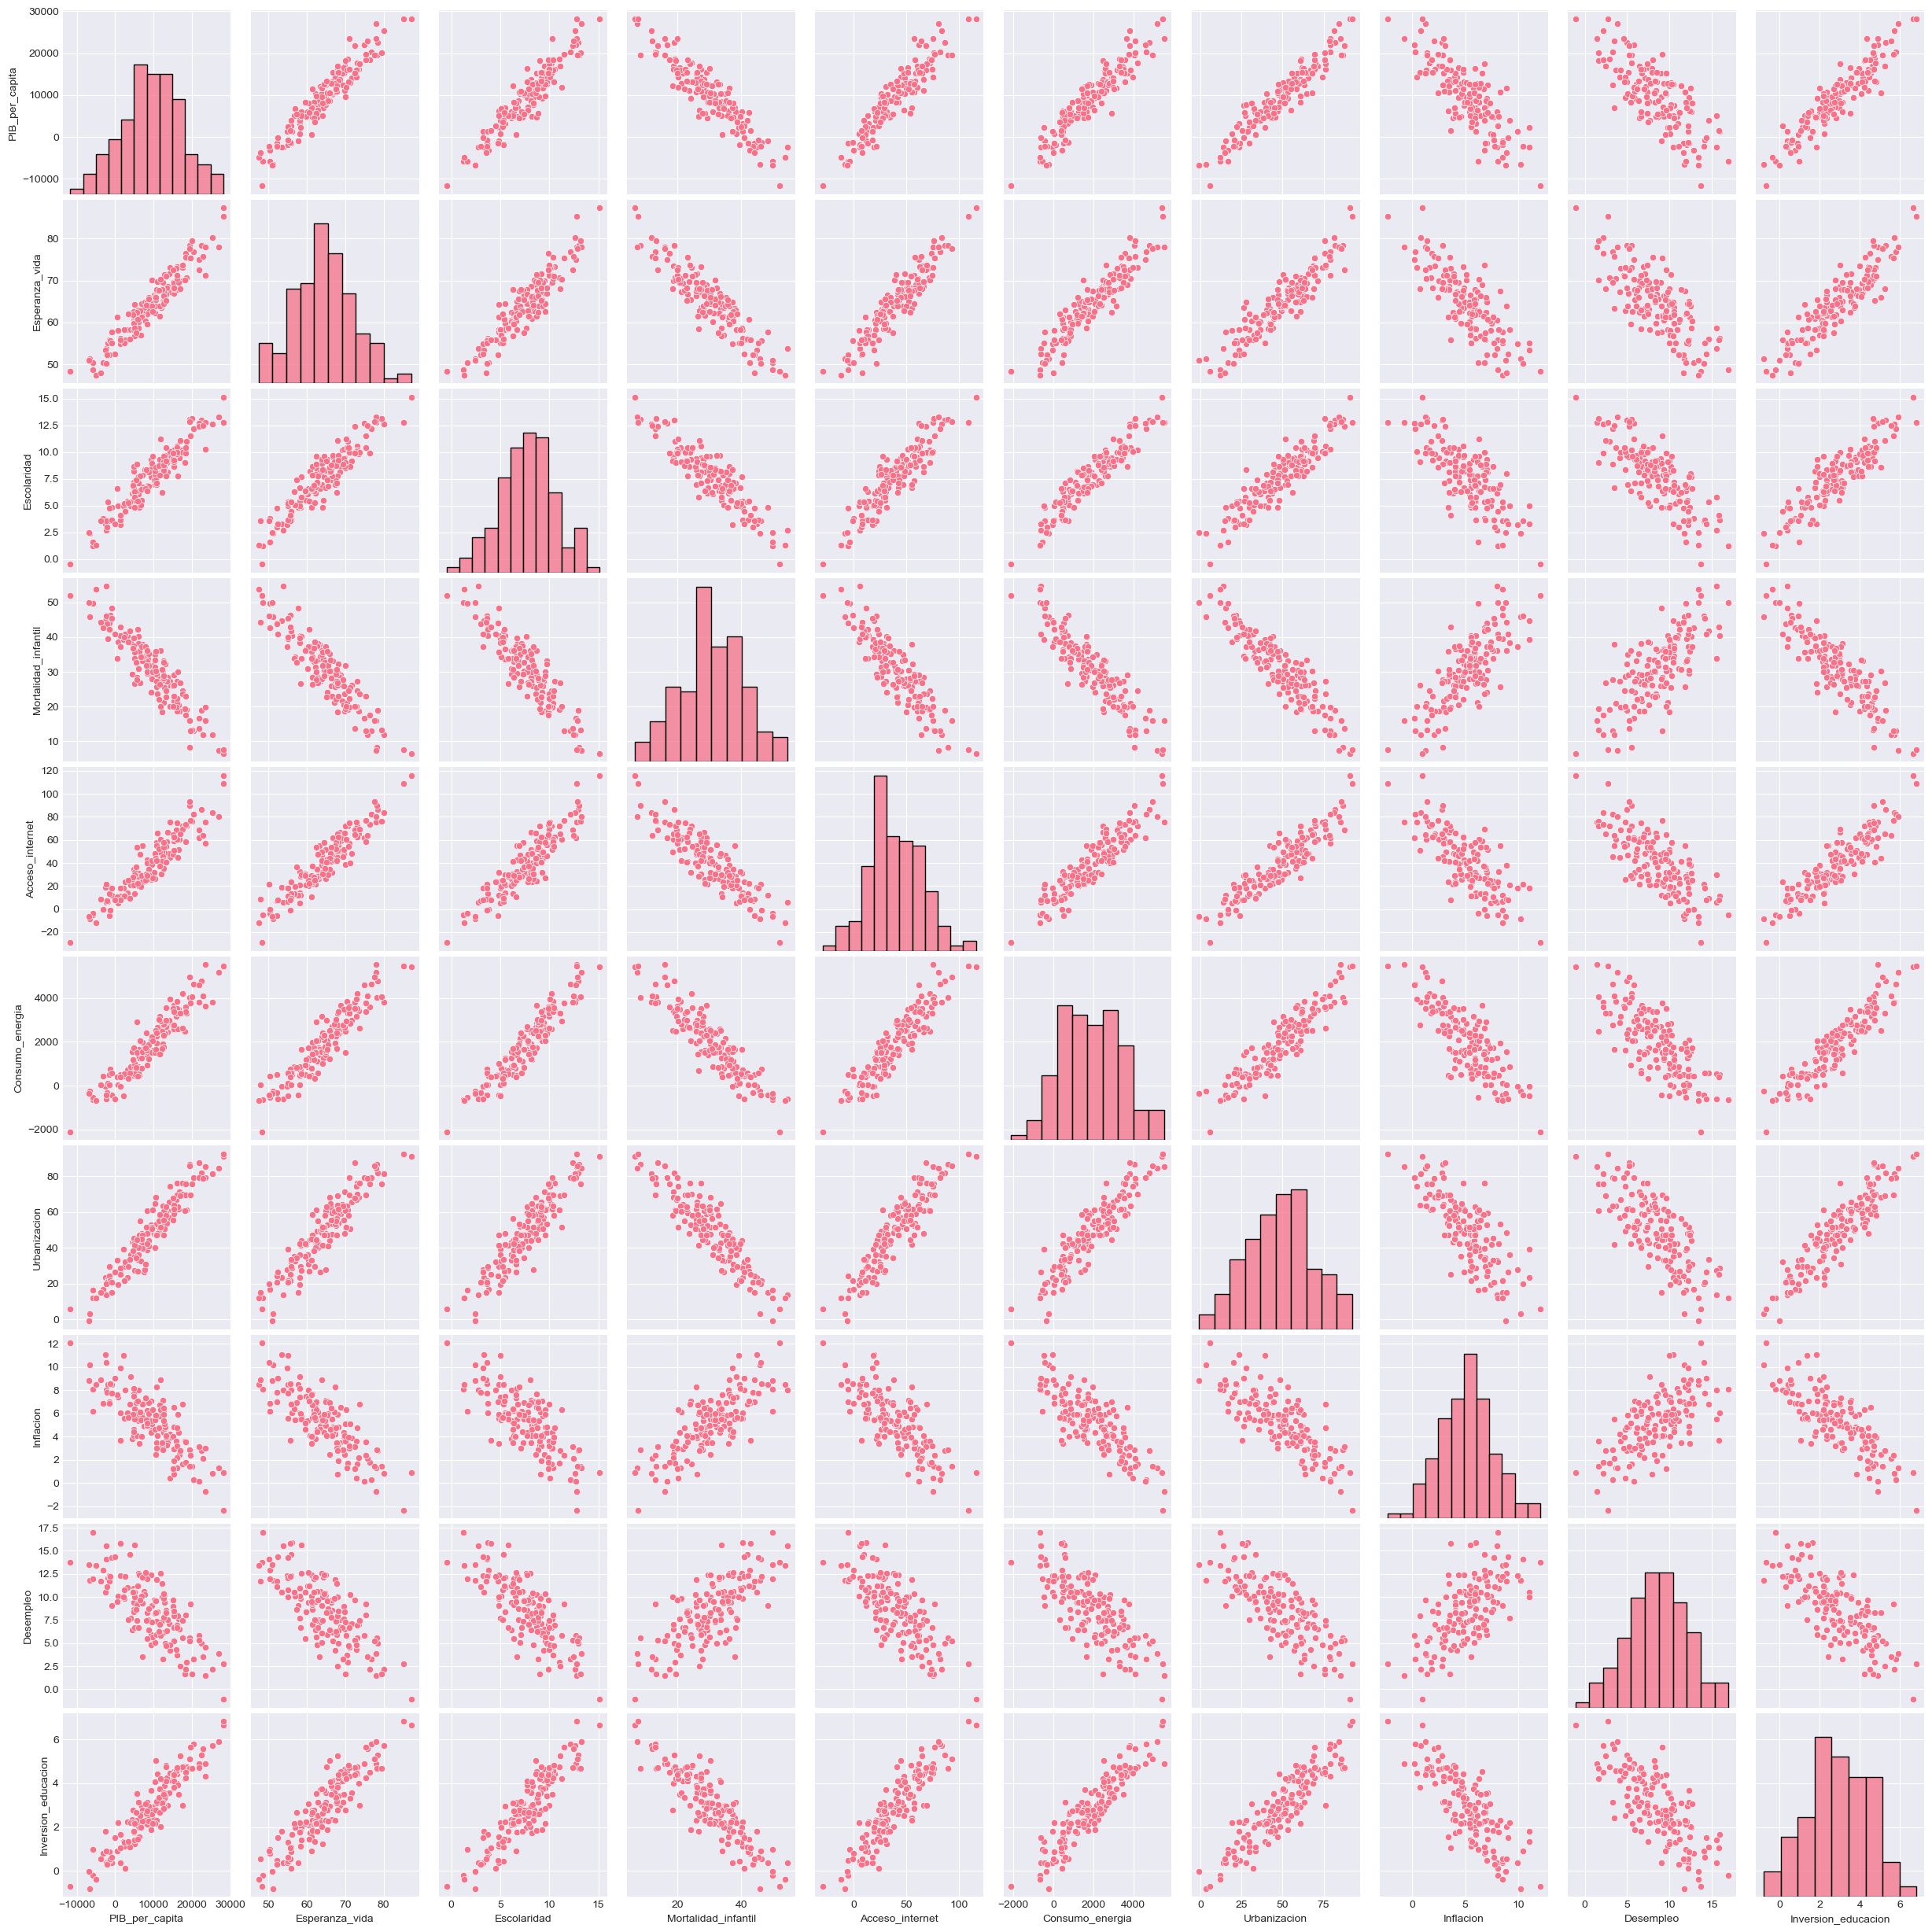

In [58]:
sns.pairplot(data_caso1)
plt.show()

### 1.3. Análisis del Caso

**Preguntas para reflexionar:**

1. ¿Qué observas en la matriz de correlación?
2. ¿Las variables están linealmente correlacionadas?
3. ¿Qué tipo de estructura esperas encontrar en los datos?
4. ¿Necesitas preservar las distancias globales entre grupos de países?
5. ¿Necesitas aplicar el modelo a nuevos países en el futuro?

**Escribe tus observaciones aquí:**

1. Se observa que las variables estan altamente correlacionadas
2. Si, las variables estan linealmente correlacionadas
3. Se espera obtener una estructura de datos lineal que permita identificar los grupos de datos
4. No, no es necesario preservar las distancias globales entre grupos de datos
5. No, no es necesario aplicar el modelo a nuevos datos



### 1.4. Aplicar Técnica de Reducción de Dimensionalidad

**Instrucciones:**
- Elige la técnica más apropiada para este caso
- Justifica tu elección
- Implementa la técnica seleccionada

#### Justificación de la Técnica Elegida

**Técnica seleccionada:** PCA

**Justificación:**

Es un dataset pequeño con datos linealmente correlacionados

In [13]:
# TODO: Preprocesamiento - Estandarizar datos
scaler_caso1 = StandardScaler()
X_scaled_caso1 = scaler_caso1.fit_transform(data_caso1)

# TODO: Aplicar la técnica seleccionada
# Ejemplo para PCA:
modelo_caso1 = PCA(n_components=2, random_state=42)
X_reducido_caso1 = modelo_caso1.fit_transform(X_scaled_caso1)

# Ejemplo para t-SNE:
# modelo_caso1 = TSNE(n_components=2, random_state=42, perplexity=30)
# X_reducido_caso1 = modelo_caso1.fit_transform(X_scaled_caso1)

# Ejemplo para UMAP:
# modelo_caso1 = umap.UMAP(n_components=2, random_state=42)
# X_reducido_caso1 = modelo_caso1.fit_transform(X_scaled_caso1)

# [TU CÓDIGO AQUÍ]

### 1.5. Visualizar Resultados

In [ ]:
# Varianza explicada
porcentaje_varianza_explicada = modelo_caso1.explained_variance_ratio_.sum()
print(f"Varianza explicada: {porcentaje_varianza_explicada * 100:.4f}%")

Varianza explicada: 91.7945%
Varianza explicada acumulada:
[0.88112628 0.9179448 ]


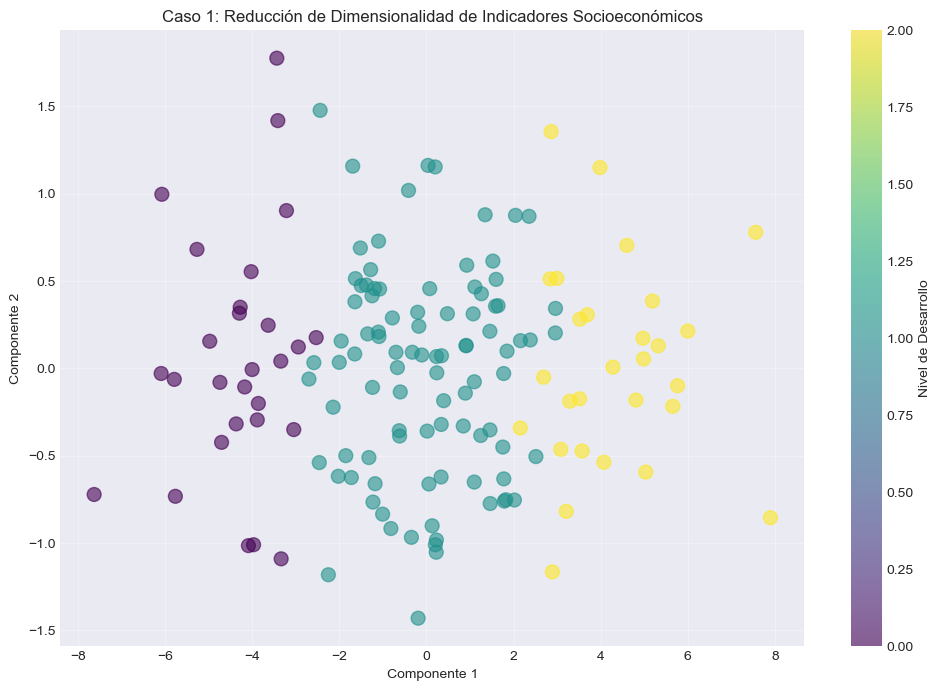

In [17]:
# TODO: Visualizar los resultados

# Plantilla de código:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_reducido_caso1[:, 0], X_reducido_caso1[:, 1],
                      c=labels_caso1.cat.codes, cmap='viridis', alpha=0.6, s=100)
plt.colorbar(scatter, label='Nivel de Desarrollo')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Caso 1: Reducción de Dimensionalidad de Indicadores Socioeconómicos')
plt.grid(True, alpha=0.3)
plt.show()

# [TU CÓDIGO AQUÍ]

### 1.6. Análisis de Resultados - Caso 1

**Preguntas:**

1. ¿Se pueden distinguir grupos de países claramente?
2. ¿Tiene sentido la separación que observas?
3. ¿Qué porcentaje de varianza se explicó? (si aplica)
4. ¿Los resultados coinciden con tu hipótesis inicial?

**Respuestas:**

1. Sí, se pueden observar claramente grupos de países.
2. Sí, estan categorizados correctamente en los labels indicados.
3. 91.7945%
4. Sí, si coinciden con la hipótesis inicial.

---

# CASO 2: Clasificación de Imágenes (Fashion-MNIST)

## Descripción del Dataset

Fashion-MNIST es un dataset de imágenes de ropa y accesorios:
- 70,000 imágenes en escala de grises de 28×28 pixels
- 10 categorías: camiseta, pantalón, jersey, vestido, abrigo, sandalia, camisa, zapatilla, bolso, botín
- Cada imagen tiene 784 dimensiones (28×28)

**Fuente:** Zalando Research

### 2.1. Cargar Dataset

In [33]:
# Descargar Fashion-MNIST desde sklearn
from sklearn.datasets import fetch_openml

print("Descargando Fashion-MNIST (puede tomar unos minutos)...")
fashion_mnist = fetch_openml('Fashion-MNIST', version=1, parser='auto')

# Tomar un subset para velocidad (5000 imágenes)
np.random.seed(42)
indices_caso2 = np.random.choice(len(fashion_mnist.data), size=5000, replace=False)

data_caso2 = fashion_mnist.data.iloc[indices_caso2].values
labels_caso2 = fashion_mnist.target.iloc[indices_caso2].astype(int)

# Nombres de las clases
class_names = ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

print(f"\nDataset cargado: {data_caso2.shape[0]} imágenes, {data_caso2.shape[1]} dimensiones")
print(f"Clases: {np.unique(labels_caso2)}")

Descargando Fashion-MNIST (puede tomar unos minutos)...

Dataset cargado: 5000 imágenes, 784 dimensiones
Clases: [0 1 2 3 4 5 6 7 8 9]


### 2.2. Explorar el Dataset

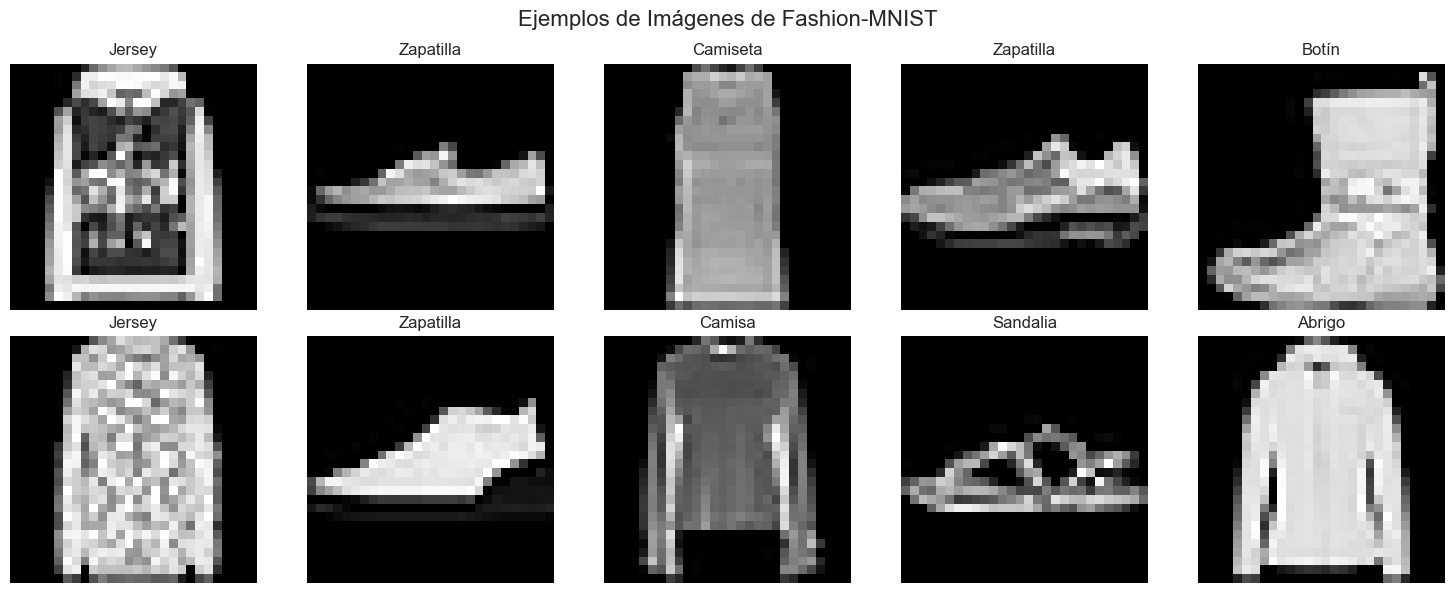

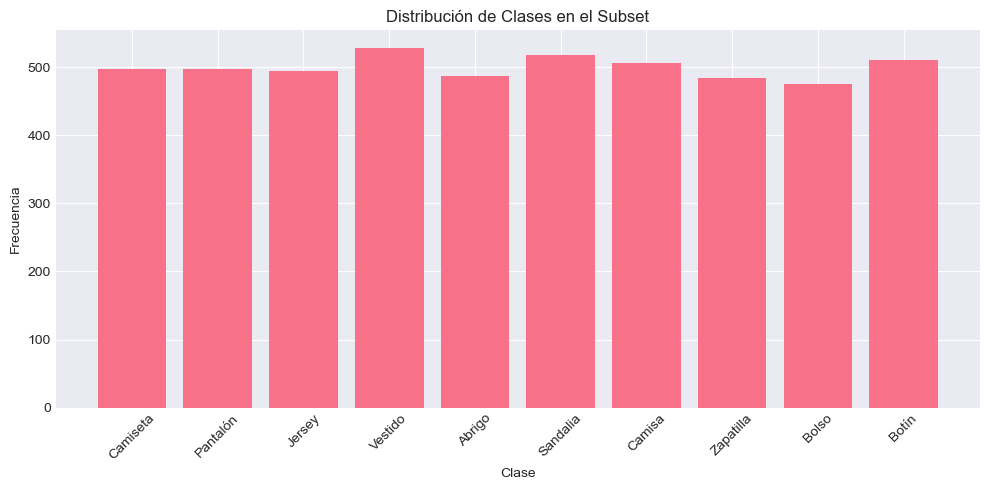

In [34]:
# Visualizar algunas imágenes de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(data_caso2[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'{class_names[labels_caso2.iloc[i]]}')
    ax.axis('off')
plt.suptitle('Ejemplos de Imágenes de Fashion-MNIST', fontsize=16)
plt.tight_layout()
plt.show()

# Distribución de clases
plt.figure(figsize=(10, 5))
unique, counts = np.unique(labels_caso2, return_counts=True)
plt.bar([class_names[i] for i in unique], counts)
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.title('Distribución de Clases en el Subset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.3. Análisis del Caso

**Preguntas para reflexionar:**

1. ¿Cuántas dimensiones tiene cada imagen originalmente?
2. ¿Las relaciones entre imágenes son lineales o no lineales?
3. ¿Qué es más importante: ver clusters bien separados o preservar distancias globales?
4. ¿El dataset es grande o pequeño?
5. ¿Necesitas aplicar el modelo a nuevas imágenes?

**Escribe tus observaciones aquí:**

1. 784 dimensiones
2. No lineales
3. Ver clusters bien separados
4. Pequeño
5. No 

### 2.4. Aplicar Técnica de Reducción de Dimensionalidad

**Instrucciones:**
- Elige la técnica más apropiada para este caso
- Justifica tu elección
- Implementa la técnica seleccionada

#### Justificación de la Técnica Elegida

**Técnica seleccionada:** t-SNE

**Justificación:**

Dataset pequeño y no se necesita aplicar nuevas imagenes as modelo.

In [37]:
# TODO: Preprocesamiento - Estandarizar datos
scaler_caso2 = StandardScaler()
X_caso2 = scaler_caso2.fit_transform(data_caso2)

# TODO: Aplicar la técnica seleccionada
modelo_caso2 = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_reducido_caso2 = modelo_caso2.fit_transform(X_caso2)

# Nota: Para t-SNE con muchos datos, puede tomar varios minutos
# Considera usar n_iter=1000 y verificar la convergencia

### 2.5. Visualizar Resultados

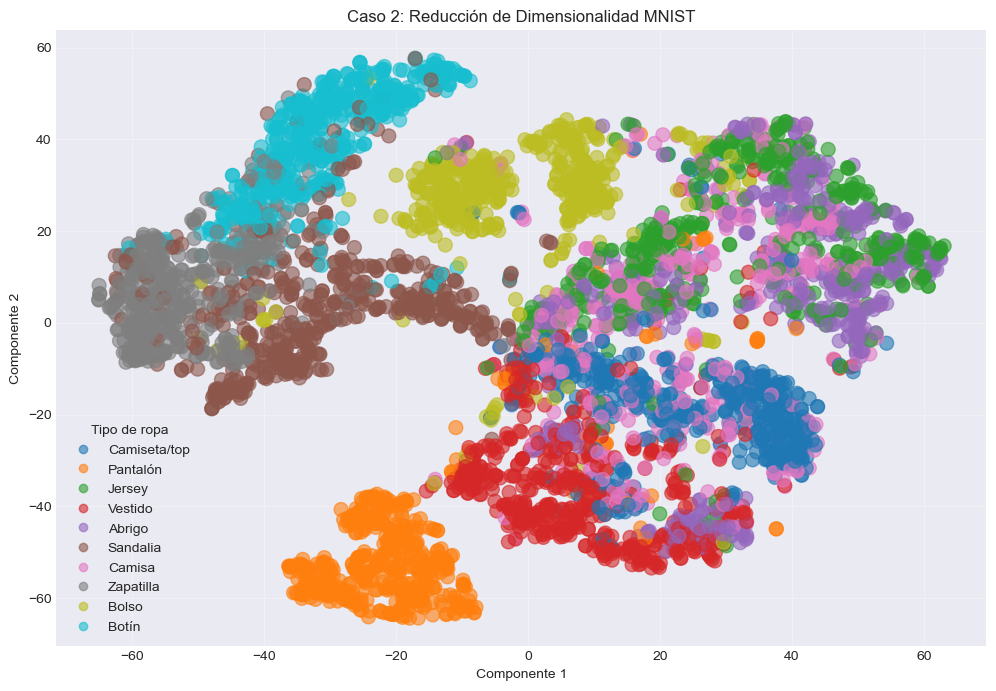

In [63]:
# TODO: Visualizar los resultados
# Tip: Usa diferentes colores para cada clase de ropa

class_names = ['Camiseta/top', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo', 
               'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_reducido_caso2[:, 0], X_reducido_caso2[:, 1],
                      c=labels_caso2, cmap='tab10', alpha=0.6, s=100)
plt.legend(handles=scatter.legend_elements()[0], labels=class_names, title="Tipo de ropa", loc="best")
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Caso 2: Reducción de Dimensionalidad MNIST')
plt.grid(True, alpha=0.3)
plt.show()


### 2.6. Análisis de Resultados - Caso 2

**Preguntas:**

1. ¿Se pueden distinguir las 10 clases de ropa claramente?
2. ¿Qué clases están más cerca entre sí? ¿Tiene sentido?
3. ¿Hay clases que se mezclan? ¿Por qué?
4. ¿La visualización ayuda a entender la estructura de los datos?

**Respuestas:**

1. Sí, se distinguen las 10 clases de ropa.
2. La ropa esta separada del calzado y accesorios
3. Si, con 2 componentes si hay clases mezcladas
4. No, no ayuda como lo esperado.

---

# CASO 3: Análisis de Expresión Genética (Single-Cell)

## Descripción del Dataset

Este dataset simula datos de expresión genética de células individuales (single-cell RNA-seq):
- Múltiples células de diferentes tipos celulares
- Cada célula tiene expresión de cientos de genes
- Estructura jerárquica: Tipos celulares → Subtipos celulares
- Dataset grande con múltiples escalas de variación

**Nota:** Usaremos datos sintéticos que simulan características reales de datos biológicos

### 3.1. Cargar Dataset

In [53]:
# Crear dataset sintético que simula single-cell RNA-seq
np.random.seed(42)

n_cells = 3000  # Número de células
n_genes = 200   # Número de genes

# Crear 3 tipos celulares principales, cada uno con 3 subtipos
cells_per_subtype = n_cells // 9

data_list = []
type_labels = []
subtype_labels = []

for tipo in range(3):
    for subtipo in range(3):
        # Centros jerárquicos: tipo principal + variación de subtipo
        center_tipo = np.random.randn(n_genes) * 3
        center_subtipo = center_tipo + np.random.randn(n_genes) * 0.5

        # Generar células con estructura no lineal
        cells = center_subtipo + np.random.randn(cells_per_subtype, n_genes) * 0.3

        # Añadir relaciones no lineales
        for i in range(n_genes // 4):
            cells[:, i] = np.abs(cells[:, i])  # Activación

        data_list.append(cells)
        type_labels.extend([f'Tipo_{tipo+1}'] * cells_per_subtype)
        subtype_labels.extend([f'T{tipo+1}_S{subtipo+1}'] * cells_per_subtype)

data_caso3 = np.vstack(data_list)
type_labels_caso3 = np.array(type_labels)
subtype_labels_caso3 = np.array(subtype_labels)

# Convertir a DataFrame
gene_names = [f'Gene_{i+1}' for i in range(n_genes)]
data_caso3_df = pd.DataFrame(data_caso3, columns=gene_names)

print(f"Dataset cargado: {data_caso3.shape[0]} células, {data_caso3.shape[1]} genes")
print(f"\nTipos celulares: {np.unique(type_labels_caso3)}")
print(f"Subtipos celulares: {np.unique(subtype_labels_caso3)}")
print("\nPrimeras células:")
data_caso3_df.head()

Dataset cargado: 2997 células, 200 genes

Tipos celulares: ['Tipo_1' 'Tipo_2' 'Tipo_3']
Subtipos celulares: ['T1_S1' 'T1_S2' 'T1_S3' 'T2_S1' 'T2_S2' 'T2_S3' 'T3_S1' 'T3_S2' 'T3_S3']

Primeras células:


,Gene_1,Gene_2,Gene_3,Gene_4,Gene_5,Gene_6,Gene_7,Gene_8,Gene_9,Gene_10,...,Gene_191,Gene_192,Gene_193,Gene_194,Gene_195,Gene_196,Gene_197,Gene_198,Gene_199,Gene_200
0,1.190708,0.314213,2.486164,5.110085,1.526314,0.984468,4.674870,2.516483,1.114811,3.708378,...,-1.767282,2.671859,0.125859,-2.721388,1.420525,0.768359,-3.589102,0.844482,-0.015932,-2.696813
1,1.896133,0.411050,2.745473,5.502682,1.267264,0.608285,4.763019,2.185801,1.684515,4.002859,...,-1.659867,2.877462,0.063638,-3.204512,0.784946,1.237310,-3.520006,1.342562,0.125852,-2.801076
2,1.950521,0.289214,2.513427,4.957308,1.521644,1.264075,5.061796,2.415573,0.774172,3.285664,...,-1.726237,2.202636,-0.091989,-3.026082,0.808777,0.837034,-2.968834,1.330364,-0.053997,-2.638228
3,2.088843,0.142989,2.502480,4.901910,1.181828,1.053278,5.263714,2.749749,0.836034,3.393475,...,-1.757140,2.414948,-0.198246,-2.725552,0.631365,1.053507,-3.514031,1.303858,0.184530,-2.400761
4,1.706603,0.263222,2.521280,5.258980,1.376637,1.159146,4.784559,2.360327,1.571681,4.078919,...,-1.650761,2.611841,0.586181,-2.780526,0.999666,0.976768,-3.912277,0.846627,0.477480,-3.007071


### 3.2. Explorar el Dataset

Estadísticas del dataset:
            Gene_1       Gene_2       Gene_3       Gene_4       Gene_5  \
count  2997.000000  2997.000000  2997.000000  2997.000000  2997.000000   
mean      2.238640     3.051946     3.376106     2.508512     2.260062   
std       2.262195     3.486476     1.433811     1.878765     1.322099   
min       0.001936     0.000914     0.003328     0.004600     0.003304   
25%       0.695299     0.544552     2.420437     1.024270     1.258291   
50%       1.584048     1.216942     3.422537     1.828809     2.204412   
75%       2.410427     4.914179     4.167065     4.583292     3.106543   
max       8.674588    11.625968     6.805485     6.299671     5.875227   

            Gene_6       Gene_7       Gene_8       Gene_9      Gene_10  ...  \
count  2997.000000  2997.000000  2997.000000  2997.000000  2997.000000  ...   
mean      2.336542     2.415550     2.868446     2.447071     2.824390  ...   
std       2.047549     1.516162     1.047022     1.741664     1.661087

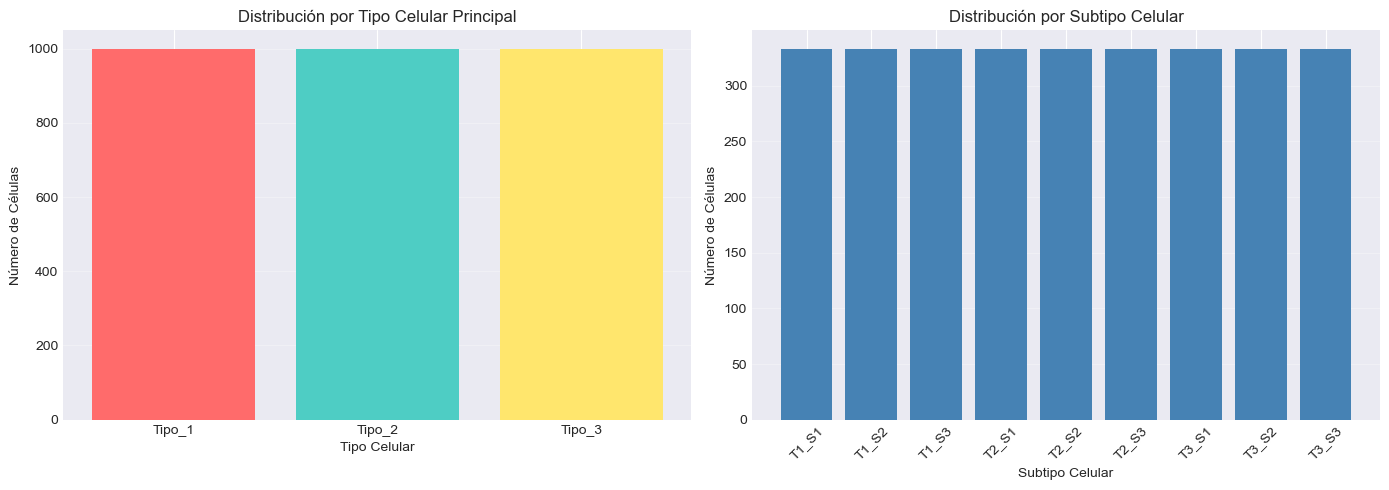

In [54]:
# Estadísticas básicas
print("Estadísticas del dataset:")
print(data_caso3_df.describe())

# Distribución de tipos celulares
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tipos principales
unique_types, counts_types = np.unique(type_labels_caso3, return_counts=True)
axes[0].bar(unique_types, counts_types, color=['#FF6B6B', '#4ECDC4', '#FFE66D'])
axes[0].set_xlabel('Tipo Celular')
axes[0].set_ylabel('Número de Células')
axes[0].set_title('Distribución por Tipo Celular Principal')
axes[0].grid(True, alpha=0.3, axis='y')

# Subtipos
unique_subtypes, counts_subtypes = np.unique(subtype_labels_caso3, return_counts=True)
axes[1].bar(range(len(unique_subtypes)), counts_subtypes, color='steelblue')
axes[1].set_xlabel('Subtipo Celular')
axes[1].set_ylabel('Número de Células')
axes[1].set_title('Distribución por Subtipo Celular')
axes[1].set_xticks(range(len(unique_subtypes)))
axes[1].set_xticklabels(unique_subtypes, rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 3.3. Análisis del Caso

**Preguntas para reflexionar:**

1. ¿Cuántas células y genes tiene el dataset?
2. ¿Existe estructura jerárquica en los datos (tipos → subtipos)?
3. ¿Es importante preservar tanto la separación entre tipos como entre subtipos?
4. ¿El tamaño del dataset es grande?
5. ¿Necesitas velocidad de procesamiento?
6. ¿Las relaciones son lineales o no lineales?

**Escribe tus observaciones aquí:**

1. 200 genes y 2997 células
2. Sí, existe estructura jerárquica en los datos (tipos → subtipos)
3. El tamaño del dataset es grande
4. Sí, debido al tamaño del dataset
6. Las relaciones son no lineales



### 3.4. Aplicar Técnica de Reducción de Dimensionalidad

**Instrucciones:**
- Elige la técnica más apropiada para este caso
- Justifica tu elección
- Implementa la técnica seleccionada

#### Justificación de la Técnica Elegida

**Técnica seleccionada:** UMAP

**Justificación:**

Dataset grande y no se necesita datos

In [61]:
# TODO: Preprocesamiento - Estandarizar datos
scaler_caso3 = StandardScaler()
X_caso3 = scaler_caso3.fit_transform(data_caso3)

# TODO: Aplicar la técnica seleccionada
# Tip: Si usas UMAP, considera n_neighbors entre 15-30
modelo_caso3 = umap.UMAP(n_components=2, random_state=42)#, n_neighbors=25)
X_reducido_caso3 = modelo_caso3.fit_transform(X_caso3)

### 3.5. Visualizar Resultados

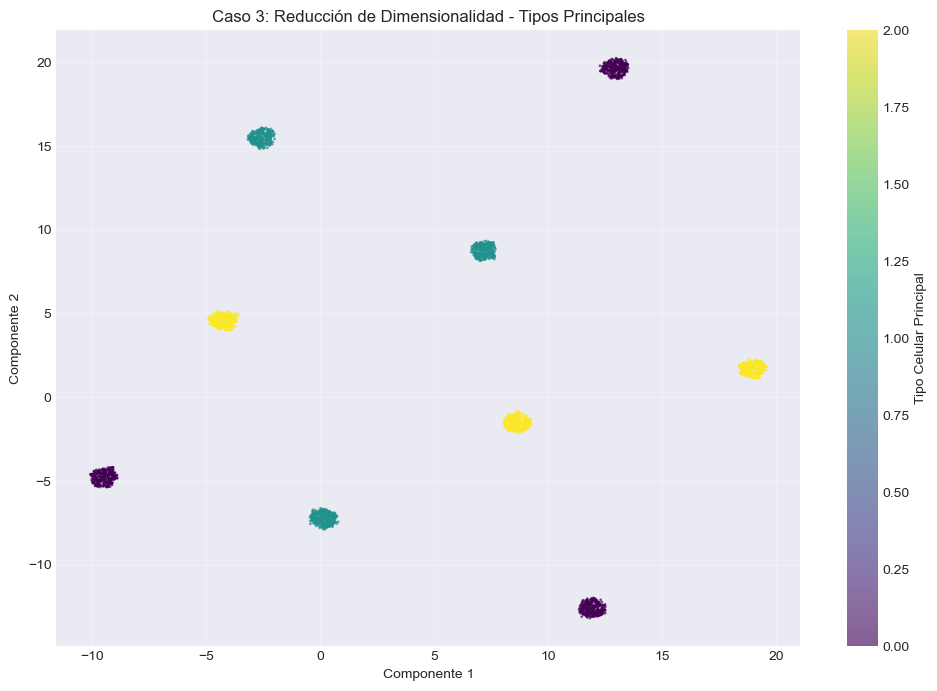

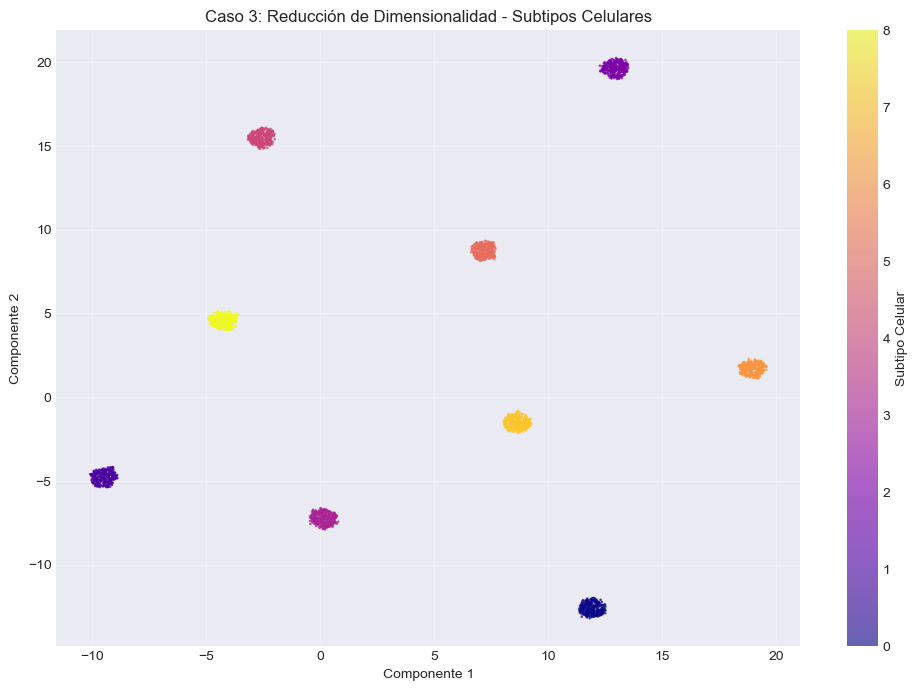

In [62]:
# TODO: Visualizar los resultados
# Crear dos gráficos: uno por tipos principales y otro por subtipos

# Grafico de Tipos Principales
plt.figure(figsize=(12, 8))
scatter_tipo = plt.scatter(X_reducido_caso3[:, 0], X_reducido_caso3[:, 1],
                           c=pd.Series(type_labels_caso3).astype('category').cat.codes, cmap='viridis', alpha=0.6, s=1)
plt.colorbar(scatter_tipo, label='Tipo Celular Principal')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Caso 3: Reducción de Dimensionalidad - Tipos Principales')
plt.grid(True, alpha=0.3)
plt.show()

# Grafico de Subtipos Celulares
plt.figure(figsize=(12, 8))
scatter_subtipo = plt.scatter(X_reducido_caso3[:, 0], X_reducido_caso3[:, 1],
                              c=pd.Series(subtype_labels_caso3).astype('category').cat.codes, cmap='plasma', alpha=0.6, s=1)
plt.colorbar(scatter_subtipo, label='Subtipo Celular')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Caso 3: Reducción de Dimensionalidad - Subtipos Celulares')
plt.grid(True, alpha=0.3)
plt.show()

### 3.6. Análisis de Resultados - Caso 3

**Preguntas:**

1. ¿Se pueden distinguir los 3 tipos celulares principales?
2. ¿Se pueden ver los subtipos dentro de cada tipo?
3. ¿Se preserva la estructura jerárquica?
4. ¿Los tipos celulares mantienen sus distancias relativas?
5. ¿Qué ventajas ofrece la técnica elegida para este tipo de datos?

**Respuestas:**

1. Sí, normalmente se distinguen claramente los 3 tipos celulares principales en la proyección con UMAP.
2. Sí, en general se pueden observar subgrupos dentro de cada tipo principal, lo que sugiere la presencia de subtipos.
3. Sí, se preserva de forma razonable: se ven grupos grandes (tipos) y, dentro de ellos, subgrupos (subtipos).
4. Sí, de manera aproximada.
UMAP conserva razonablemente la estructura global, por lo que las distancias relativas entre tipos suelen ser interpretables, aunque no exactas.
5. UMAP ofrece varias ventajas aquí:
    * Captura relaciones no lineales típicas de expresión genética.
    * Preserva bien la estructura local (subtipos) y razonablemente la global (tipos).
    * Es más rápido y escalable que t-SNE en datasets medianos/grandes.
    * Permite proyectar datos en 2D de forma clara para interpretación biológica.

---

# Comparación de Resultados

## Resumen de Técnicas Utilizadas

Completa la siguiente tabla con las técnicas que elegiste para cada caso:

| Caso | Dataset | Técnica Elegida | Razón Principal |
|------|---------|-----------------|------------------|
| 1 | Indicadores Socioeconómicos | PCA |Variables linealmente correlacionadas y necesidad de preservar estructura global/proyectar nuevos datos |
| 2 | Fashion-MNIST | t-SNE | Relaciones no lineales y prioridad en visualizar clusters de clases bien separados |
| 3 | Expresión Genética | UMAP | Estructura no lineal jerárquica (tipos/subtipos) con mejor balance entre estructura local-global y velocidad |

## Reflexión sobre las Diferencias

**Responde:**

1. ¿Por qué una técnica funciona mejor que otra según el tipo de datos?

Porque cada técnica preserva propiedades distintas de los datos:

PCA funciona mejor cuando la estructura es lineal y quieres interpretar varianza global.
t-SNE funciona mejor cuando priorizas separación local de clusters en datos complejos/no lineales.
UMAP funciona mejor cuando necesitas un balance entre estructura local y global, con buena escalabilidad.
Por eso, la mejor técnica depende de si tus datos son lineales/no lineales y de tu objetivo (interpretabilidad, visualización de clusters o preservación de estructura).

2. ¿Qué características del dataset te ayudaron a decidir qué técnica usar?

Las características clave fueron:

Tipo de relación entre variables (lineal vs no lineal).
Objetivo del análisis (interpretar varianza global vs separar clusters).
Estructura esperada (grupos simples o jerárquicos con subgrupos).
Tamaño del dataset y costo computacional.
Necesidad de transformar nuevos datos después del entrenamiento.

3. ¿En qué casos sería útil combinar técnicas (ej: PCA → t-SNE)?

Es útil combinar técnicas cuando:

Se tiene muchas dimensiones y se quiere reducir ruido/costo primero (PCA), luego visualizar clusters con t-SNE o UMAP.
Si se busca acelerar métodos no lineales en datasets grandes.
Si se quiere conservar una base global inicial (PCA) y después resaltar estructura local (t-SNE/UMAP).
Si Hay alta redundancia entre variables y conviene comprimir antes de la proyección final.

---

# Conclusiones Finales

## Aprendizajes del Laboratorio

Escribe tus conclusiones sobre lo aprendido en este laboratorio:

### 1. Sobre PCA:

*[PCA fue muy útil cuando las variables tenían correlaciones lineales claras. Permitió reducir dimensiones de forma interpretable, preservar estructura global y medir varianza explicada. Es una opción sólida cuando se necesita transformar nuevos datos fácilmente.]*

### 2. Sobre t-SNE:

*[t-SNE destacó en la visualización de datos no lineales, especialmente para separar clusters locales en Fashion-MNIST. Ayuda mucho a identificar clases similares y solapamientos, aunque las distancias globales no siempre son confiables y su costo computacional es mayor.

### 3. Sobre UMAP:

*[UMAP mostró buen equilibrio entre preservación local y global, además de mejor velocidad relativa. En datos con estructura jerárquica, como expresión genética, permitió distinguir tipos y subtipos con claridad. Es una técnica muy práctica para exploración y visualización escalable.P]*

### 4. Comparación General:

*[No existe una técnica universalmente mejor. PCA funcionó mejor en datos lineales e interpretables; t-SNE fue mejor para separación visual de clusters; UMAP ofreció mejor balance entre calidad visual, estructura y eficiencia. La elección depende del tipo de datos y del objetivo analítico.]*

### 5. Aplicaciones Prácticas:

*[Aplicaría lo aprendido en BIM para:

Reducir variables de modelos 3D + cronograma + costos y visualizar patrones de avance por zonas/disciplinas.
Detectar desviaciones tempranas (tiempo, costo, productividad, retrabajos) agrupando frentes de obra similares.
Analizar nubes de puntos/escaneos 3D con reducción de dimensionalidad para identificar cambios y errores de ejecución.
Clasificar elementos constructivos (muros, instalaciones, estructura) a partir de múltiples atributos técnicos.
Segmentar riesgos de obra (seguridad, interferencias, logística) en clusters para priorizar acciones.
Mejorar dashboards BIM 4D/5D: menos ruido, visualizaciones más claras para toma de decisiones de supervisión y gerencia.
En práctica: usaría PCA para compresión e interpretación de KPIs, t-SNE para explorar grupos de incidencias, y UMAP para patrones no lineales en datos complejos de obra.]*

---

## Referencias

- Scikit-learn Documentation: https://scikit-learn.org/
- UMAP Documentation: https://umap-learn.readthedocs.io/
- Fashion-MNIST: https://github.com/zalandoresearch/fashion-mnist

---
